# Transformée de Fourier: études de cas

In [67]:
# import
import matplotlib.pyplot as plt; from scipy.io import wavfile
%run ./init.py

## Transformée de Fourier d'une porte

Un enregistrement a un début et une fin = enregistrer un son, c'est le multiplier par une porte / fenêtre temporelle. 
**Multiplier par une porte en temporel, c'est convoler par la TF de cette porte en fréquentiel**. Quel effet sur le contenu spectral?

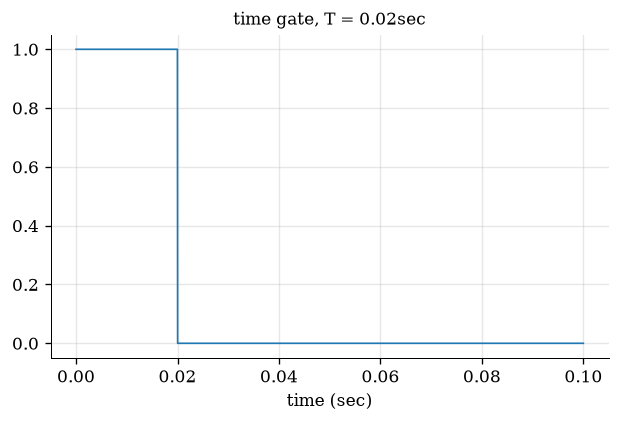

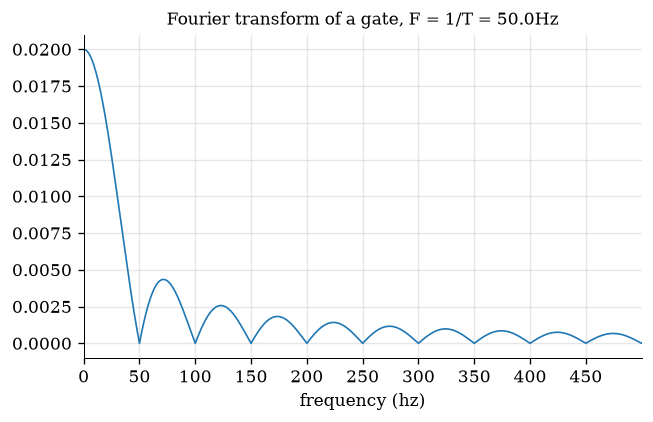

In [68]:
# create gate
duration_in_sec = 0.1
t = np.arange(0, duration_in_sec*fs)/fs
x = np.zeros_like(t)
time_gate = 0.02
x[t < time_gate] = 1

# plot
plt.plot(t, x);
plt.xlabel('time (sec)'); plt.title(f'time gate, T = {time_gate}sec'); plt.show();

# fft
n = 10*len(x)
X = np.fft.rfft(x, n) / n
freqs = np.fft.rfftfreq(n, 1/fs)

# plot
plt.plot(freqs, np.abs(X));
plt.xlim([0, 10/time_gate]); 
plt.xticks(np.arange(0, 10/time_gate, 1/time_gate))
plt.title(f'Fourier transform of a gate, F = 1/T = {1/time_gate}Hz'); plt.xlabel('frequency (hz)'); plt.show();

La TF d'une porte $Π_{-T/2}^{T/2}(t) = 1$ pour $ -T/2 ≤ t ≤ T/2 $ est un sinus cardinal $ T.sinc(\pi f t)$. On voit l'effet de la convolution avec ce $sinc$ sur nos signaux, tronqués depuis le début, si on augmente la résolution de la transformée de Fourier.

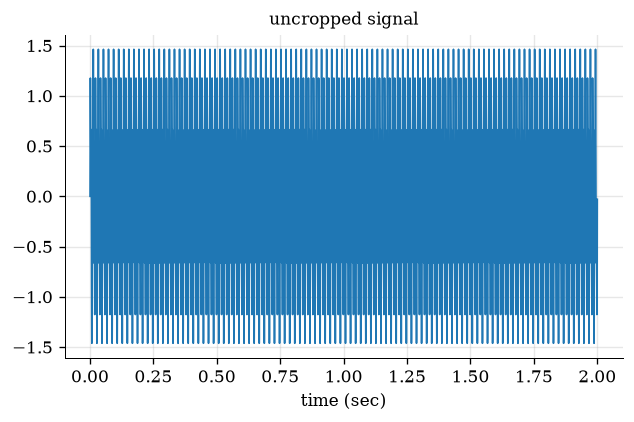

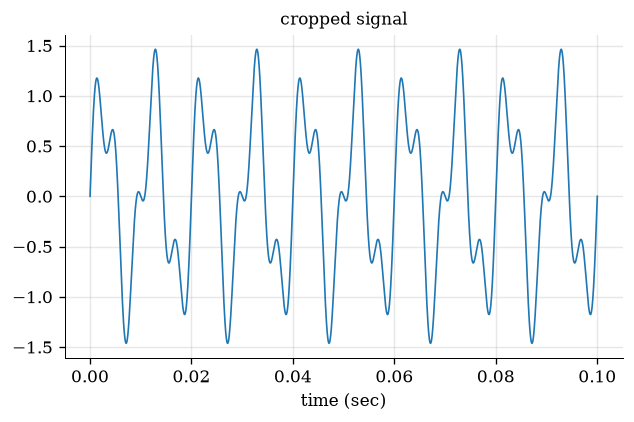

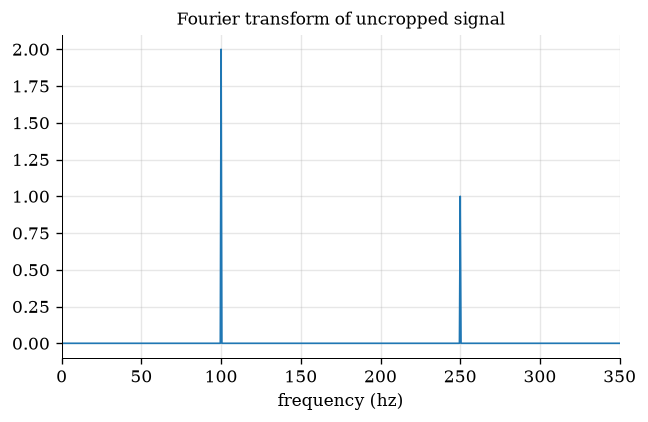

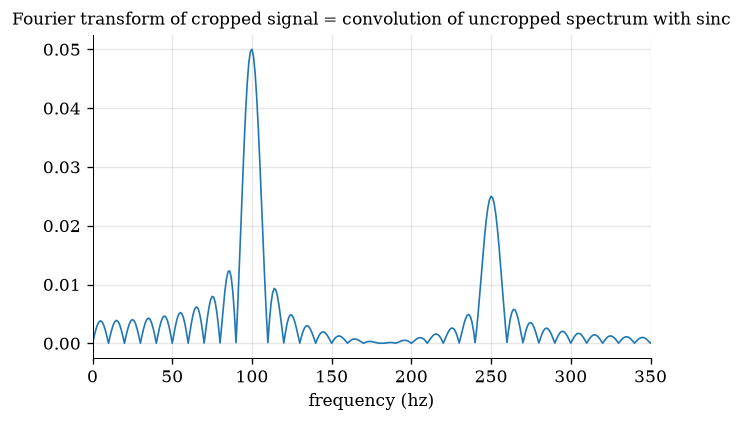

In [69]:
# create signal
duration_in_sec = 2
f1 = 100; f2 = 250;
x1, t = get_sine(f1, sampling_rate = fs, duration_in_sec = duration_in_sec)
x2, t = get_sine(f2, sampling_rate = fs, duration_in_sec = duration_in_sec)
x = x1 + 0.5 * x2

# fft
n = len(x)
X = np.fft.rfft(x, n) / len(X)
freqs = np.fft.rfftfreq(n, 1/fs)

# plot
plt.plot(t, x);
plt.title('uncropped signal'); plt.xlabel('time (sec)'); plt.show();

# truncate
selvect = t < 0.1
t = t[selvect]; x = x[selvect]

# plot
plt.plot(t, x);
plt.title('cropped signal'); plt.xlabel('time (sec)'); plt.show();


# plot
plt.plot(freqs, np.abs(X));
plt.xlim([f1-100, f2+100]); plt.title('Fourier transform of uncropped signal'); 
plt.xlabel('frequency (hz)'); plt.show();

# fft
n = 10*len(x)
X = np.fft.rfft(x, n) / len(X)
freqs = np.fft.rfftfreq(n, 1/fs)

# plot
plt.plot(freqs, np.abs(X));
plt.xlim([f1-100, f2+100]); plt.title('Fourier transform of cropped signal = convolution of uncropped spectrum with sinc'); 
plt.xlabel('frequency (hz)'); plt.show();

De façon générale, on préférera utiliser des portes avec des pentes plus douces pour éviter ces ondulations dans le spectre.

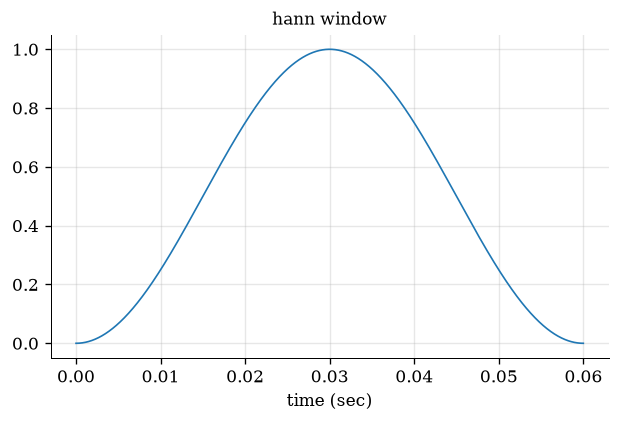

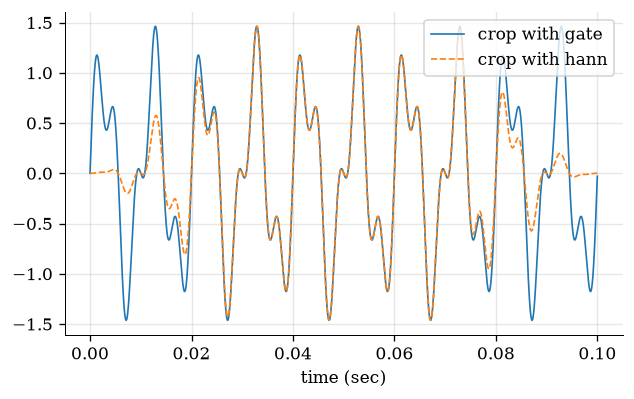

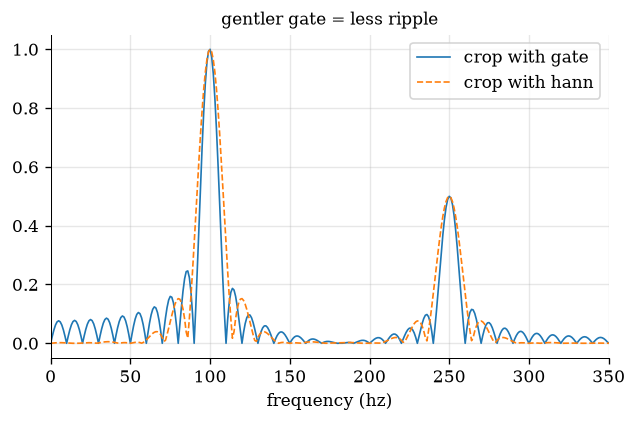

In [70]:
# create signal
duration_in_sec = 0.1
f1 = 100; f2 = 250;
x1, t = get_sine(f1, sampling_rate = fs, duration_in_sec = duration_in_sec)
x2, t = get_sine(f2, sampling_rate = fs, duration_in_sec = duration_in_sec)
x = x1 + 0.5 * x2
y = np.copy(x)

# create gate
fadein_duration_in_sec = 0.3 * duration_in_sec
fadein_duration_in_samp = int(fadein_duration_in_sec*2*fs)
w = scipy.signal.windows.hann(int(fadein_duration_in_sec*2*fs))
n = int(len(w)/2)

# plot
plt.plot(np.arange(0, len(w))/fs, w); 
plt.xlabel('time (sec)'); plt.title('hann window'); plt.show()

# truncate
y[1:n] *= w[1:n]
y[-n:] *= w[-n:]

# plot
plt.plot(t, x, label = 'crop with gate');
plt.plot(t, y, '--', label = 'crop with hann');
plt.legend(); plt.xlabel('time (sec)'); plt.show();

# fft
n = 10*len(x)
X = np.fft.rfft(x, n) / n
Y = np.fft.rfft(y, n) / n
freqs = np.fft.rfftfreq(n, 1/fs)

# plot
plt.plot(freqs, np.abs(X) / np.max(np.abs(X)), label = 'crop with gate');
plt.plot(freqs, np.abs(Y) / np.max(np.abs(Y)), '--', label = 'crop with hann');
plt.legend();
# plt.yscale('log')
plt.xlim([f1-100, f2+100]); plt.title('gentler gate = less ripple'); plt.xlabel('frequency (hz)'); plt.show();


## Transformée de Fourier d'un peigne

Échantillonner un signal, c'est le multiplier par un peigne. **Multiplier par un peigne en temporel, c'est convoler par la TF de ce peigne en fréquentiel**. Quel effet sur le contenu spectral?


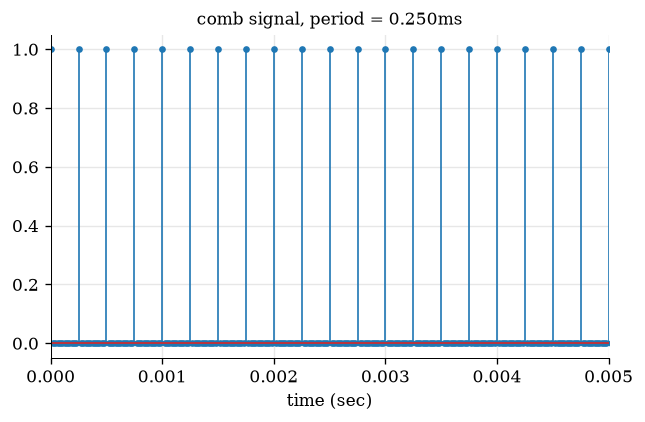

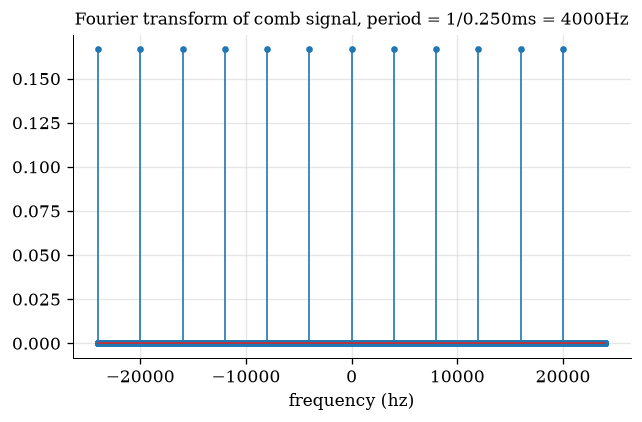

In [71]:
def get_comb(f1, fs, duration_in_sec = 1):

    # Time positions where we want an impulse
    impulse_times = np.arange(0, duration_in_sec, 1/f1)

    # Convert times to sample numbers
    impulse_samples = np.round(impulse_times * fs).astype(int)

    # Create the signal
    comb = np.zeros(int(duration_in_sec * fs))
    comb[impulse_samples] = 1

    return comb

# create comb
duration_in_sec = 1
comb_sampling_freq = fs/12 # expect freq ripples if fs / comb_sampling_freq not integer
x = get_comb(comb_sampling_freq, fs = fs, duration_in_sec = duration_in_sec)
t = np.arange(0, duration_in_sec*fs)/fs

# plot
plt.stem(t, x);
plt.xlabel('time (sec)'); plt.title(f'comb signal, period = {1000/comb_sampling_freq:0.3f}ms'); 
plt.xlim([0, 0.005]); plt.show();

# fft
n = 1*len(x)
X = np.fft.fft(x, n) / len(X)
freqs = np.fft.fftfreq(n, 1/fs)

# plot
plt.stem(freqs, np.abs(X));
# plt.xlim([0, 1000]); 
plt.title(f'Fourier transform of comb signal, period = 1/{1000/comb_sampling_freq:0.3f}ms = {comb_sampling_freq:0.0f}Hz'); plt.xlabel('frequency (hz)'); 
# plt.xticks(np.arange(-comb_sampling_freq*10, comb_sampling_freq*10, comb_sampling_freq)); plt.xlim([-fs/2, fs/2]);
plt.show();

La TF d'un peigne "$Ш_{T}(t) = 1$ pour $t = nT$" est un peigne $Ш_{1/T}(f)$. 

Cette convolution avec un peigne du spectre (copie périodique) est à l'origine du **repliement spectral** observé sur un signal contenant des fréquences supérieures à $Fs/2$.

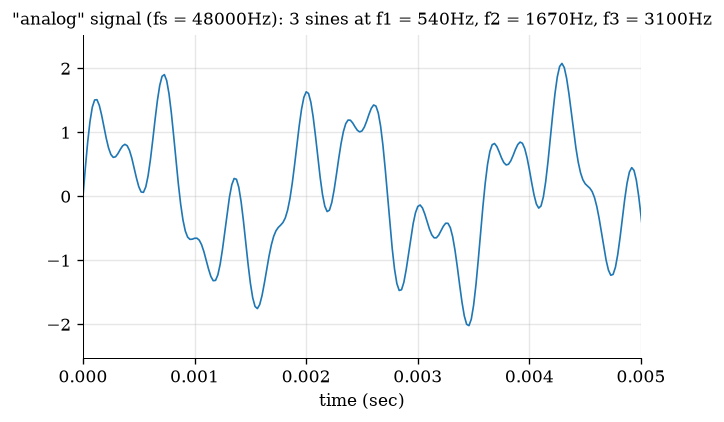

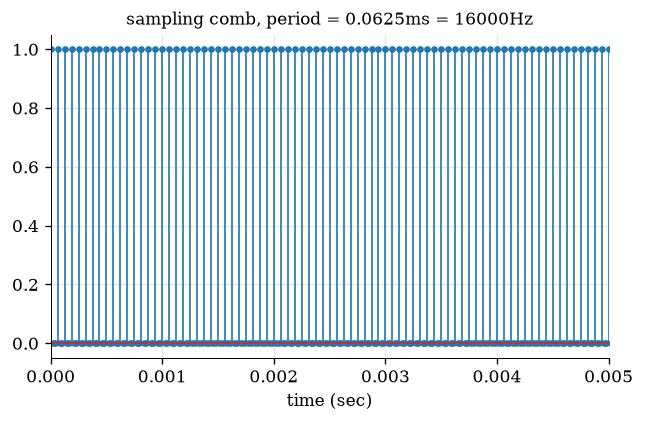

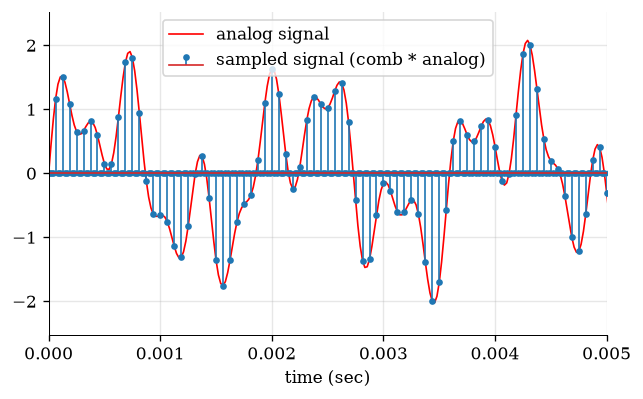

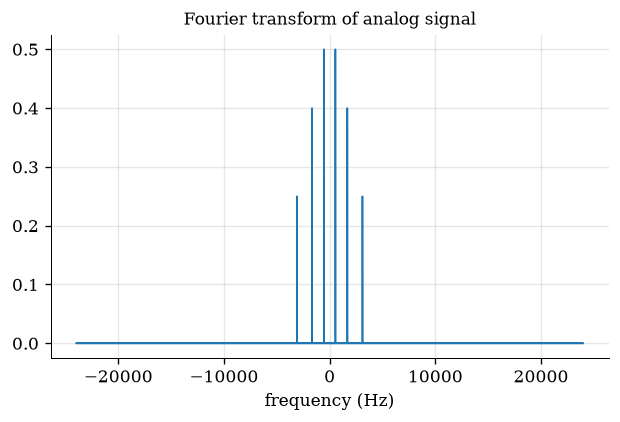

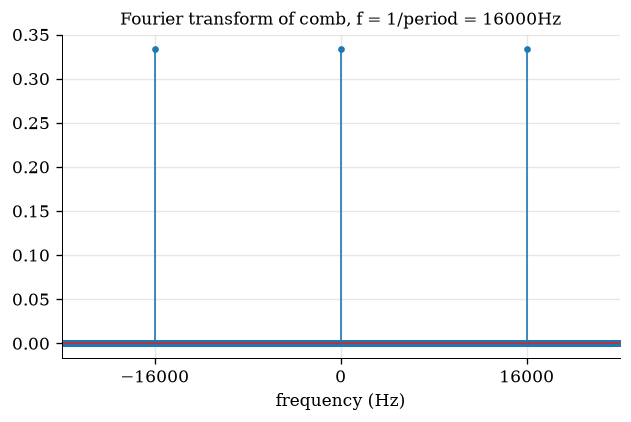

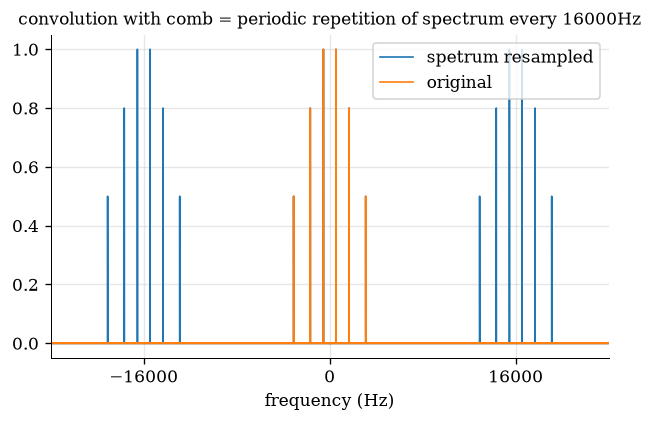

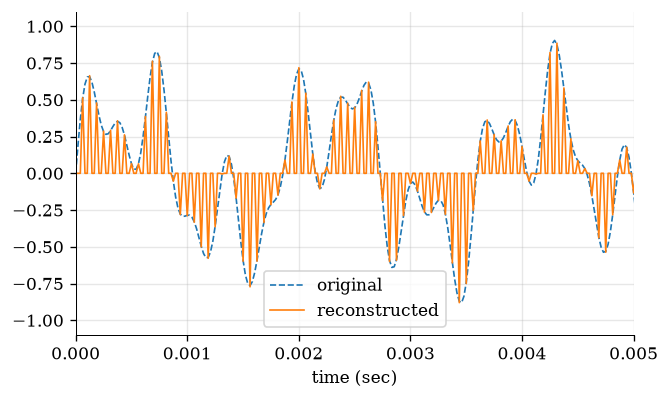

In [72]:
# init locals
comb_sampling_freq = fs/3
# expect freq ripples if fs / comb_sampling_freq not integer
# fs/3: no overlap but can't hear impact even without filter (on mbp speakers anyway)
# fs/6: no overlap and can hear impact 
# fs/12 overlap (filter won't help anymore)

# create signal
duration_in_sec = 1
f1 = 540; f2 = 1670; f3 = 3100
x1, t = get_sine(f1, sampling_rate = fs, duration_in_sec = duration_in_sec)
x2, t = get_sine(f2, sampling_rate = fs, duration_in_sec = duration_in_sec)
x3, t = get_sine(f3, sampling_rate = fs, duration_in_sec = duration_in_sec)
x = x1 + 0.8 * x2 + 0.5 * x3

# play
playsound(x, fs)

# plot
plt.plot(t, x)
plt.xlim([0, 0.005]); plt.title(f'"analog" signal (fs = {fs}Hz): 3 sines at f1 = {f1}Hz, f2 = {f2}Hz, f3 = {f3}Hz'); 
plt.xlabel('time (sec)'); plt.show();

# fft
n = 1*len(x)
X = np.fft.fft(x, n) / len(x)
freqs = np.fft.fftfreq(n, 1/fs)

# create comb
w = get_comb(comb_sampling_freq, fs = fs, duration_in_sec = duration_in_sec)

# plot
plt.stem(t, w)
plt.title(f'sampling comb, period = {1000/comb_sampling_freq:0.3}ms = {comb_sampling_freq:0.0f}Hz'); plt.xlim([0, 0.005]); 
plt.xlabel('time (sec)'); plt.show();

# emulate resampling
y = w * x

# plot
plt.plot(t, x, color = 'r', label = 'analog signal')
plt.stem(t, y, label = 'sampled signal (comb * analog)')
plt.xlabel('time (sec)'); plt.xlim([0, 0.005]); plt.legend(); plt.show();

# plot
plt.plot(freqs, np.abs(X))
plt.title('Fourier transform of analog signal'); 
plt.xlabel('frequency (Hz)'); plt.show();

# fft
n = len(w)
W = np.fft.fft(w, n) / n

# plot
plt.stem(freqs, np.abs(W))
plt.title(f'Fourier transform of comb, f = 1/period = {comb_sampling_freq:0.0f}Hz');
plt.xticks(np.arange(-comb_sampling_freq*10, comb_sampling_freq*10, comb_sampling_freq)); plt.xlim([-fs/2, fs/2]);
plt.xlabel('frequency (Hz)'); plt.show()

# fft
n = len(y)
Y = np.fft.fft(y, n) / len(y)
freqs = np.fft.fftfreq(n, 1/fs)

# plot
plt.plot(freqs, np.abs(Y) / np.max(np.abs(Y)), label = 'spetrum resampled')
plt.plot(freqs, np.abs(X) / np.max(np.abs(X)), label = 'original')
plt.title(f'convolution with comb = periodic repetition of spectrum every {comb_sampling_freq:0.0f}Hz')
plt.xticks(np.arange(-comb_sampling_freq*10, comb_sampling_freq*10, comb_sampling_freq)); plt.xlim([-fs/2, fs/2]);
plt.legend(); plt.xlabel('frequency (Hz)'); plt.show();

# ifft
n = 1*len(Y)
y = np.fft.irfft(Y, n)
t = np.arange(0, len(y)) / fs

# play 
playsound(y, fs)

# plot
plt.plot(t, x / np.max(np.abs(x)), '--', label = 'original');
plt.plot(t, y / np.max(np.abs(y)), label = 'reconstructed');
plt.legend(); plt.xlabel('time (sec)'); plt.xlim([0, 0.005]);
plt.show()


applying a low pass filter can help prevent aliasing if no overlap of frequencies of interest

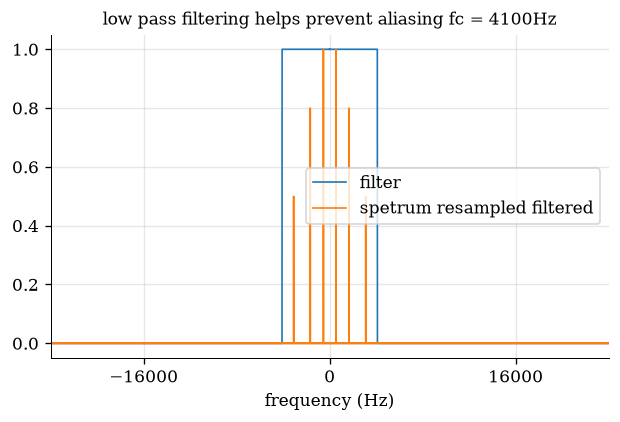

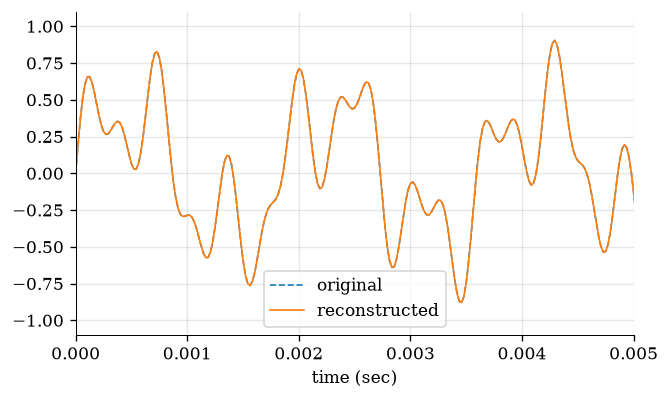

In [73]:
# create and apply
G = np.zeros_like(freqs)
fc = f3 + 1000
G[np.abs(freqs) < fc] = 1
Y_filtered = G * Y

# plot
plt.plot(freqs, G, label = 'filter')
plt.plot(freqs, np.abs(Y_filtered) / np.max(np.abs(Y_filtered)), label = 'spetrum resampled filtered')
plt.title(f'low pass filtering helps prevent aliasing fc = {fc:0.0f}Hz')
plt.xticks(np.arange(-comb_sampling_freq*10, comb_sampling_freq*10, comb_sampling_freq)); plt.xlim([-fs/2, fs/2]);
plt.xlabel('frequency (Hz)'); plt.legend(); plt.show();

# ifft
n = 1*len(Y_filtered)
y_filtered = np.fft.irfft(Y_filtered, n)
t = np.arange(0, len(y_filtered)) / fs

# play 
playsound(y_filtered, fs)

# plot
plt.plot(t, x / np.max(np.abs(x)), '--', label = 'original');
plt.plot(t, y_filtered / np.max(np.abs(y_filtered)), label = 'reconstructed');
plt.legend(); plt.xlim([0, 0.005]); plt.xlabel('time (sec)')
plt.show()

# Resources additionnelles

- [transformées de Fourier usuelles](https://fr.wikiversity.org/wiki/Transform%C3%A9es_de_Fourier_usuelles)
- autre TF à implémenter pour vérifier les résultats du cours
    - tf d'un Dirac (c.f. TdS1_Ch1_Cplts_Ch1_Ch2_table_TF.pdf)
    - translation temporelle = déphasage fréquentiel (TdS1_Ch1_Cplts_Ch1_Ch2_table_TF.pdf)
    - modulation temporelle = translation fréquentielle (TdS1_Ch1_Cplts_Ch1_Ch2_table_TF.pdf)
    - dérivation temporelle = multiplication fréquentielle (récursif) (TdS1_Ch1_Cplts_Ch1_Ch2_table_TF.pdf)